In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as plt
df=pd.read_excel("bigmart.csv.xlsx")
df

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.930,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052
...,...,...,...,...,...,...,...,...,...,...,...,...
8518,FDF22,6.865,Low Fat,0.056783,Snack Foods,214.5218,OUT013,1987,High,Tier 3,Supermarket Type1,2778.3834
8519,FDS36,8.380,Regular,0.046982,Baking Goods,108.1570,OUT045,2002,NaN,Tier 2,Supermarket Type1,549.2850
8520,NCJ29,10.600,Low Fat,0.035186,Health and Hygiene,85.1224,OUT035,2004,Small,Tier 2,Supermarket Type1,1193.1136
8521,FDN46,7.210,Regular,0.145221,Snack Foods,103.1332,OUT018,2009,Medium,Tier 3,Supermarket Type2,1845.5976


In [2]:
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [4]:
df.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


In [5]:
df.isnull().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [6]:
#handling null values
#similar product have similar weight so i used this method
df["Item_Weight"] = df.groupby("Item_Type")["Item_Weight"]\
.transform(lambda x: x.fillna(x.median()))

In [7]:
df.isnull().sum()

Item_Identifier                 0
Item_Weight                     0
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [8]:
# handling outlet_size null value using mode
mode_outlet_size = df["Outlet_Size"].mode()[0]

df["Outlet_Size"].fillna(mode_outlet_size, inplace=True)

C:\Users\zaim1\AppData\Local\Temp\ipykernel_5980\2530981280.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Outlet_Size"].fillna(mode_outlet_size, inplace=True)


In [9]:
df.isnull().sum()

Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64

<Axes: xlabel='Item_Visibility'>

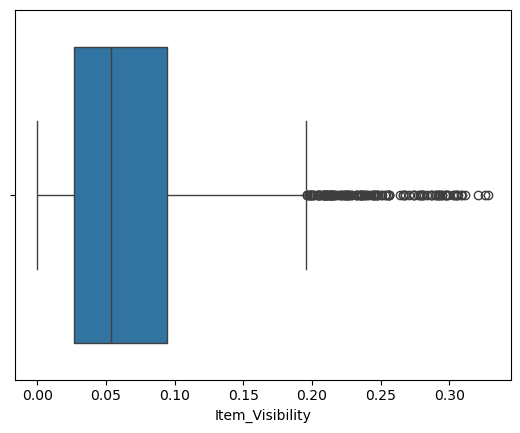

In [10]:
#outliers
sns.boxplot(x="Item_Visibility",data=df) #Usually has many outliers so no need to handle outlier because it is a possible situation.

<Axes: xlabel='Item_Weight'>

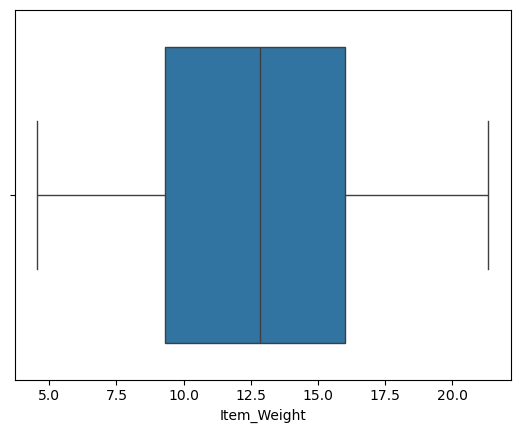

In [11]:
sns.boxplot(x="Item_Weight",data=df) # there are no outliers in item weight 

<Axes: xlabel='Item_MRP'>

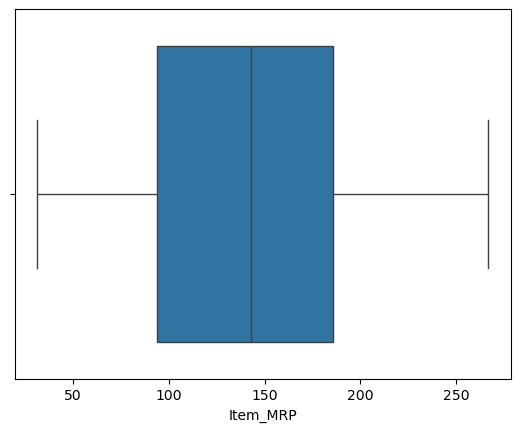

In [12]:
sns.boxplot(x="Item_MRP",data=df) #there are no outlier in item mrp

<Axes: xlabel='Item_Outlet_Sales'>

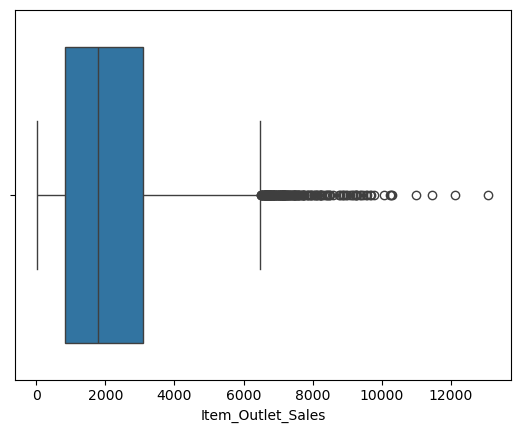

In [13]:
sns.boxplot(x="Item_Outlet_Sales",data=df) # item outlet sales May also show high-value outliers because some products
                                            #naturally sell more so its a possible situation and no need to handle outliers.

In [14]:
#Item Type vs Total Sales
df.groupby("Item_Type")["Item_Outlet_Sales"].sum().sort_values(ascending=False)

Item_Type
Fruits and Vegetables    2.820060e+06
Snack Foods              2.732786e+06
Household                2.055494e+06
Frozen Foods             1.825735e+06
Dairy                    1.522594e+06
Canned                   1.444151e+06
Baking Goods             1.265525e+06
Health and Hygiene       1.045200e+06
Meat                     9.175656e+05
Soft Drinks              8.928977e+05
Breads                   5.532372e+05
Hard Drinks              4.577934e+05
Starchy Foods            3.514013e+05
Others                   3.255176e+05
Breakfast                2.322990e+05
Seafood                  1.488682e+05
Name: Item_Outlet_Sales, dtype: float64

C:\Users\zaim1\AppData\Local\Temp\ipykernel_5980\1365747557.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


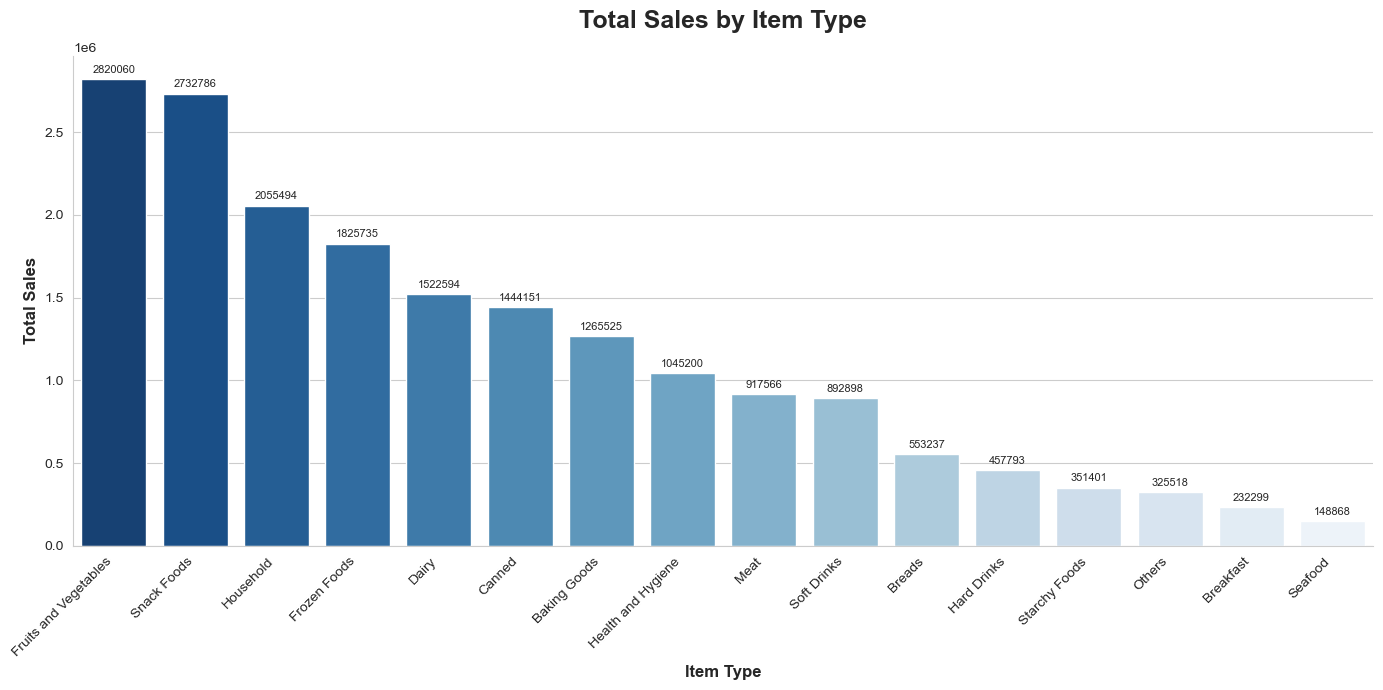

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Total sales by item type
item_sales = (
    df.groupby("Item_Type")["Item_Outlet_Sales"]
    .sum()
    .sort_values(ascending=False)
)

# Corporate theme
sns.set_style("whitegrid")

plt.figure(figsize=(14, 7))

ax = sns.barplot(
    x=item_sales.index,
    y=item_sales.values,
    palette="Blues_r"  # Professional blue gradient
)

# Formatting
plt.title(
    "Total Sales by Item Type",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.xlabel("Item Type", fontsize=12, fontweight="bold")
plt.ylabel("Total Sales", fontsize=12, fontweight="bold")

plt.xticks(rotation=45, ha="right")

# Format sales labels on bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.0f',
        fontsize=8,
        padding=3
    )

# Remove unnecessary borders
sns.despine(left=False, bottom=False)

plt.tight_layout()
plt.show()

In [16]:
#Outlet Type vs Average Sales
outlet_sales = df.groupby("Outlet_Type")["Item_Outlet_Sales"].mean().sort_values(ascending=False)

print(outlet_sales)

Outlet_Type
Supermarket Type3    3694.038558
Supermarket Type1    2316.181148
Supermarket Type2    1995.498739
Grocery Store         339.828500
Name: Item_Outlet_Sales, dtype: float64


C:\Users\zaim1\AppData\Local\Temp\ipykernel_5980\1040966704.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


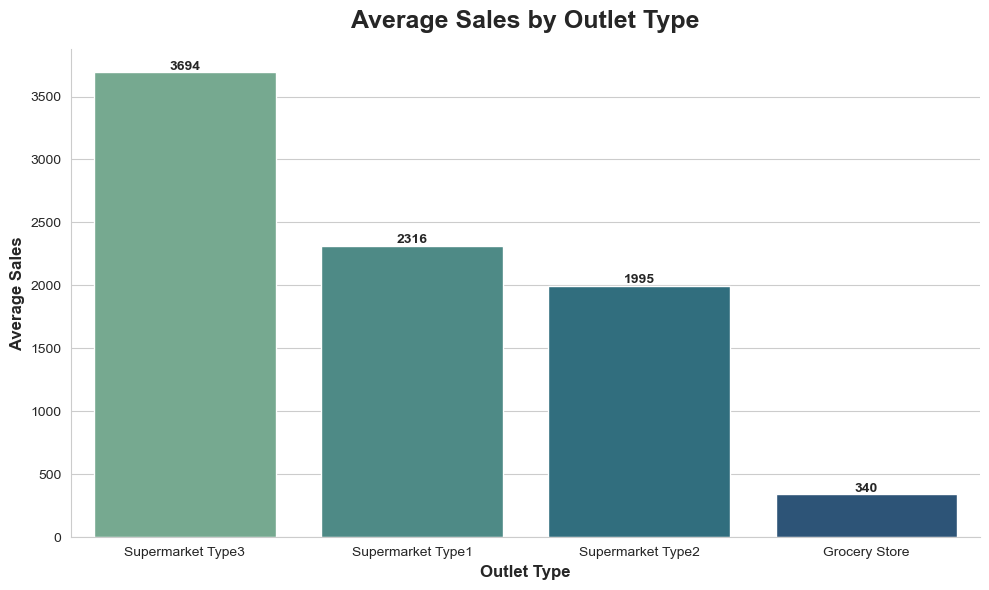

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Corporate theme
sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=outlet_sales.index,
    y=outlet_sales.values,
    palette="crest"
)

# Title
plt.title(
    "Average Sales by Outlet Type",
    fontsize=18,
    fontweight="bold",
    pad=15
)

# Axis labels
plt.xlabel("Outlet Type", fontsize=12, fontweight="bold")
plt.ylabel("Average Sales", fontsize=12, fontweight="bold")

# Value labels on bars
for i, value in enumerate(outlet_sales.values):
    plt.text(
        i,
        value + 20,
        f"{value:.0f}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

# Clean appearance
sns.despine()
plt.tight_layout()

plt.show()

In [18]:
#Outlet Size vs Sales
outlet_size_sales = (
    df.groupby("Outlet_Size")["Item_Outlet_Sales"]
    .mean()
    .sort_values(ascending=False)
)

print(outlet_size_sales)

Outlet_Size
High      2298.995256
Medium    2283.730470
Small     1912.149161
Name: Item_Outlet_Sales, dtype: float64


C:\Users\zaim1\AppData\Local\Temp\ipykernel_5980\3597508650.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


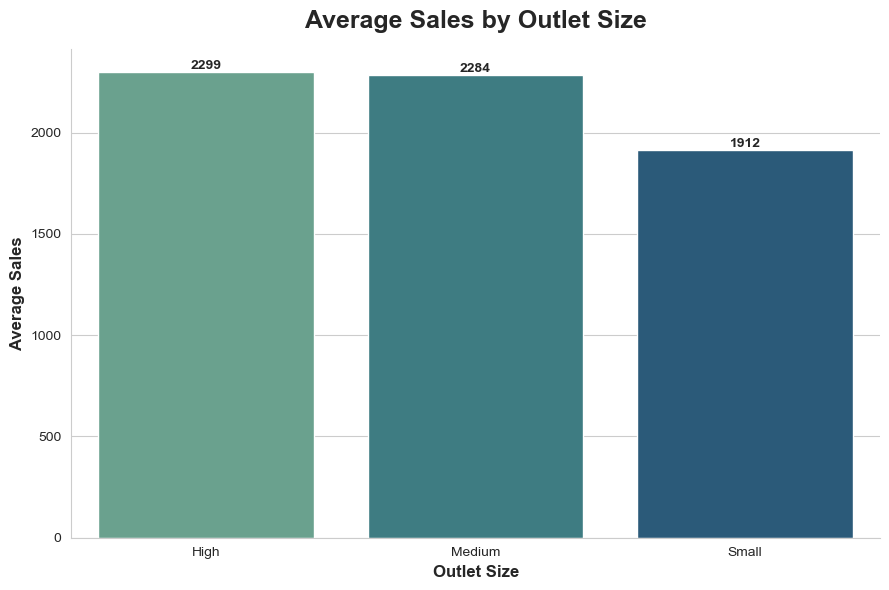

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Corporate style
sns.set_style("whitegrid")

plt.figure(figsize=(9, 6))

ax = sns.barplot(
    x=outlet_size_sales.index,
    y=outlet_size_sales.values,
    palette="crest"
)

# Title
plt.title(
    "Average Sales by Outlet Size",
    fontsize=18,
    fontweight="bold",
    pad=15
)

# Labels
plt.xlabel("Outlet Size", fontsize=12, fontweight="bold")
plt.ylabel("Average Sales", fontsize=12, fontweight="bold")

# Value labels
for i, value in enumerate(outlet_size_sales.values):
    plt.text(
        i,
        value + 15,
        f"{value:.0f}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

# Clean corporate look
sns.despine()
plt.tight_layout()

plt.show()

In [20]:
#Fat Content vs Sales
fat_content_sales = (
    df.groupby("Item_Fat_Content")["Item_Outlet_Sales"]
    .mean()
    .sort_values(ascending=False)
)

print(fat_content_sales)

Item_Fat_Content
Regular    2235.186702
Low Fat    2164.477336
low fat    2087.740737
LF         2073.551928
reg        1962.192268
Name: Item_Outlet_Sales, dtype: float64


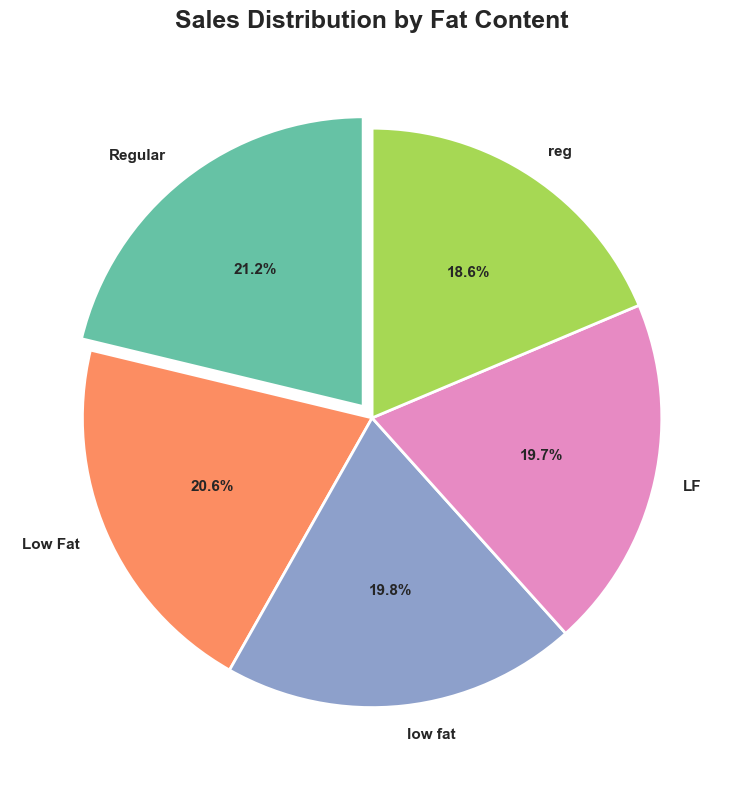

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Modern corporate colors
colors = sns.color_palette("Set2")

plt.figure(figsize=(8, 8))

explode = [0.05] + [0] * (len(fat_content_sales) - 1)

plt.pie(
    fat_content_sales.values,
    labels=fat_content_sales.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    explode=explode,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 11, 'fontweight': 'bold'}
)

plt.title(
    "Sales Distribution by Fat Content",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.tight_layout()
plt.show()

In [22]:
#Item Visibility vs Sales
visibility_sales_corr = df["Item_Visibility"].corr(df["Item_Outlet_Sales"])

print("Correlation between Item Visibility and Sales:", visibility_sales_corr) 

#Interpretation
#+0.7 to +1.0 → Strong positive relationship
#+0.3 to +0.7 → Moderate positive relationship
#0 to +0.3 → Weak positive relationship
#0 to -0.3 → Weak negative relationship
#-0.3 to -0.7 → Moderate negative relationship
#-0.7 to -1.0 → Strong negative relationship

Correlation between Item Visibility and Sales: -0.12862461222077032


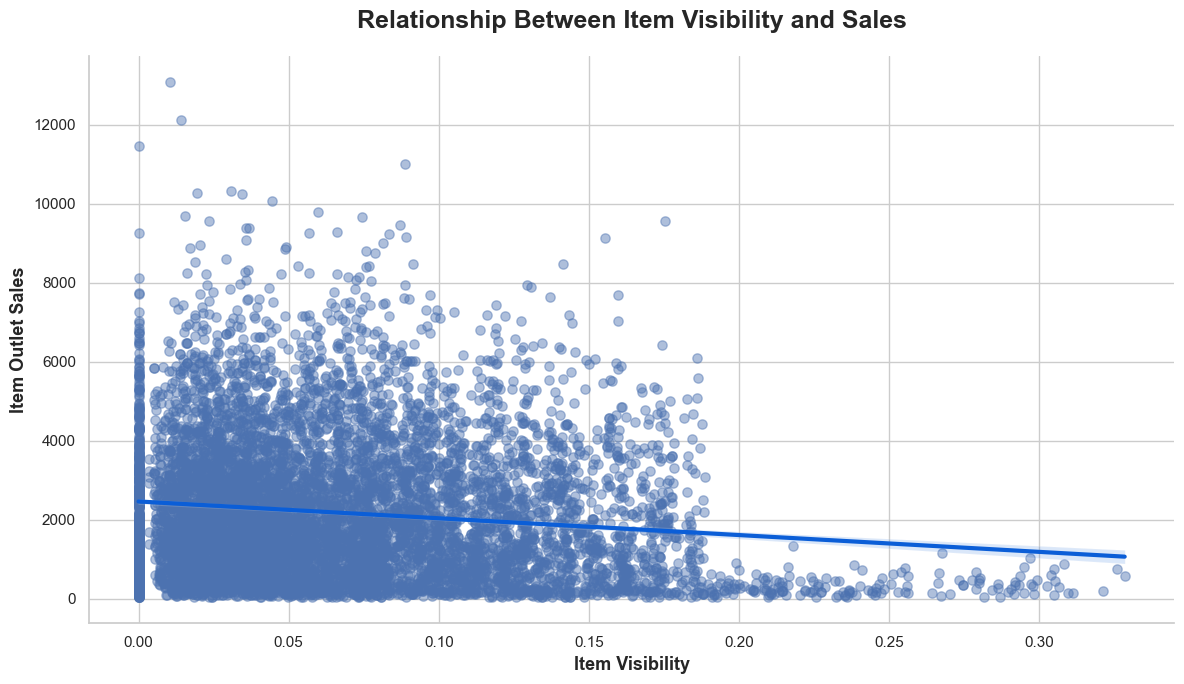

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Corporate theme
sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 7))

# Scatter plot with trend line
sns.regplot(
    data=df,
    x="Item_Visibility",
    y="Item_Outlet_Sales",
    scatter_kws={
        "alpha": 0.45,
        "s": 45
    },
    line_kws={
        "color": "#0B5ED7",
        "linewidth": 3
    }
)

# Title and labels
plt.title(
    "Relationship Between Item Visibility and Sales",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.xlabel(
    "Item Visibility",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel(
    "Item Outlet Sales",
    fontsize=13,
    fontweight="bold"
)

# Clean look
sns.despine()
plt.tight_layout()

plt.show()

In [24]:
#Item MRP vs Sales
df["MRP_Group"] = pd.cut(
    df["Item_MRP"],
    bins=5
)

mrp_sales = (
    df.groupby("MRP_Group")["Item_Outlet_Sales"]
    .mean()
    .sort_values(ascending=False)
)

print(mrp_sales)

MRP_Group
(219.769, 266.888]    3776.521195
(172.649, 219.769]    2977.243593
(125.529, 172.649]    2326.425618
(78.41, 125.529]      1593.626878
(31.054, 78.41]        786.911067
Name: Item_Outlet_Sales, dtype: float64


C:\Users\zaim1\AppData\Local\Temp\ipykernel_5980\3980131024.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("MRP_Group")["Item_Outlet_Sales"]


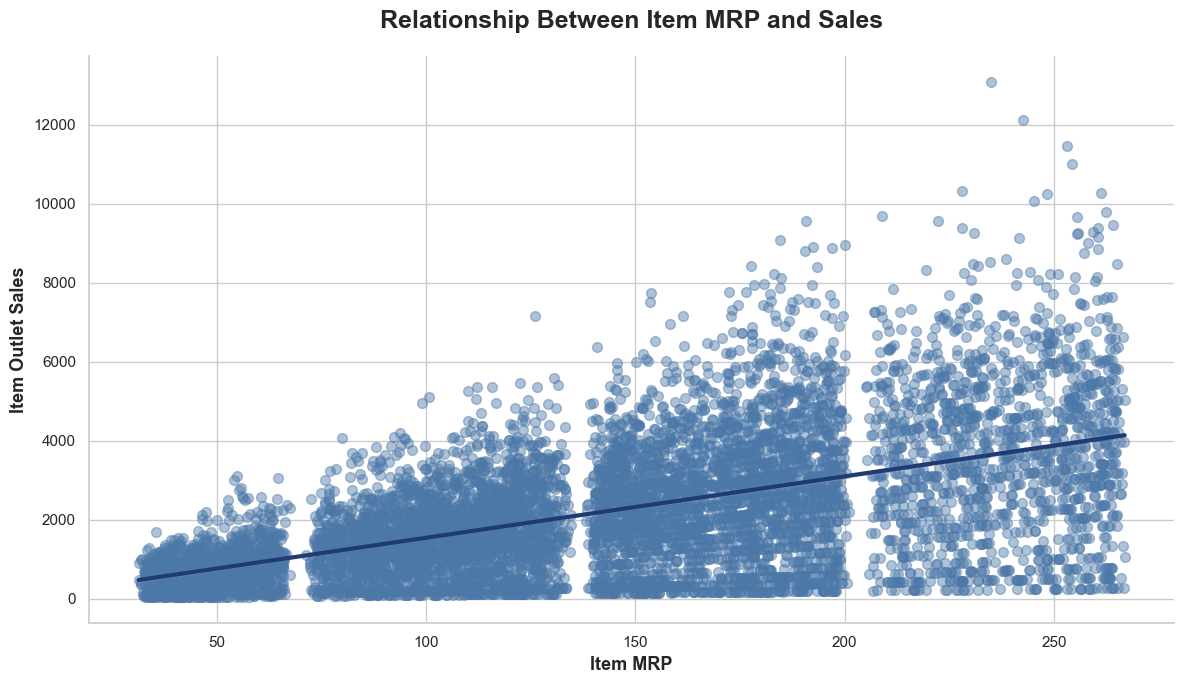

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Corporate theme
sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 7))

# Scatter plot with regression line
sns.regplot(
    data=df,
    x="Item_MRP",
    y="Item_Outlet_Sales",
    scatter_kws={
        "alpha": 0.45,
        "s": 50,
        "color": "#4C78A8"
    },
    line_kws={
        "color": "#1F3B73",
        "linewidth": 3
    }
)

# Title
plt.title(
    "Relationship Between Item MRP and Sales",
    fontsize=18,
    fontweight="bold",
    pad=20
)

# Labels
plt.xlabel(
    "Item MRP",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel(
    "Item Outlet Sales",
    fontsize=13,
    fontweight="bold"
)

# Clean corporate look
sns.despine()
plt.tight_layout()

plt.show()

In [26]:
#Outlet Location Type vs Sales
location_sales = (
    df.groupby("Outlet_Location_Type")["Item_Outlet_Sales"]
    .mean()
    .sort_values(ascending=False)
)

print(location_sales)

Outlet_Location_Type
Tier 2    2323.990559
Tier 3    2279.627651
Tier 1    1876.909159
Name: Item_Outlet_Sales, dtype: float64


C:\Users\zaim1\AppData\Local\Temp\ipykernel_5980\2210332495.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


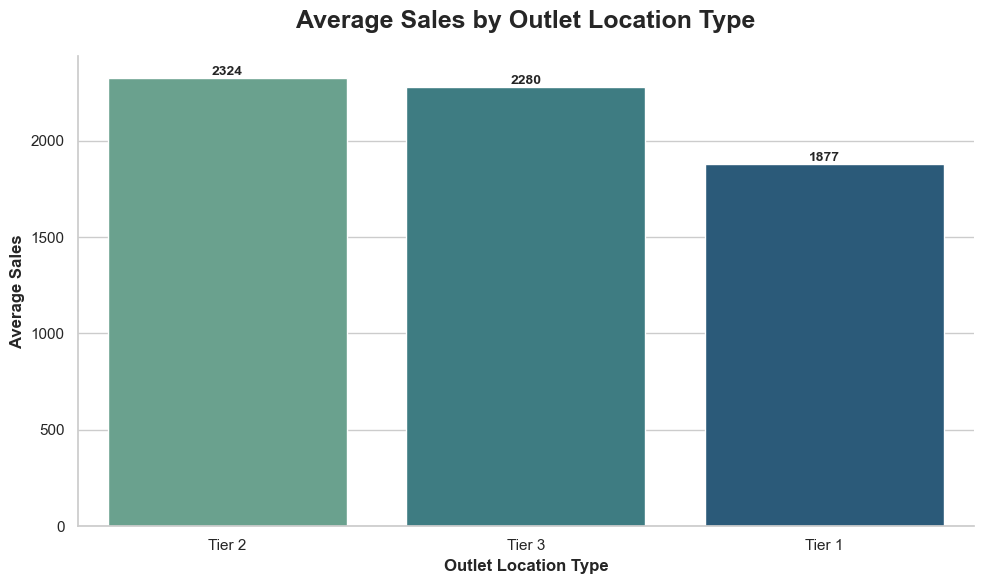

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Corporate theme
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=location_sales.index,
    y=location_sales.values,
    palette="crest"
)

# Title
plt.title(
    "Average Sales by Outlet Location Type",
    fontsize=18,
    fontweight="bold",
    pad=20
)

# Axis labels
plt.xlabel(
    "Outlet Location Type",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Average Sales",
    fontsize=12,
    fontweight="bold"
)

# Value labels
for i, value in enumerate(location_sales.values):
    plt.text(
        i,
        value + 15,
        f"{value:.0f}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

# Clean look
sns.despine()
plt.tight_layout()

plt.show()

In [28]:
#Outlet Establishment Year vs Sales
year_sales = (
    df.groupby("Outlet_Establishment_Year")["Item_Outlet_Sales"]
    .mean()
    .sort_values()
)

print(year_sales)

Outlet_Establishment_Year
1998     339.351662
2009    1995.498739
2002    2192.384798
1997    2277.844267
1987    2298.995256
2007    2340.675263
1999    2348.354635
2004    2438.841866
1985    2483.677474
Name: Item_Outlet_Sales, dtype: float64


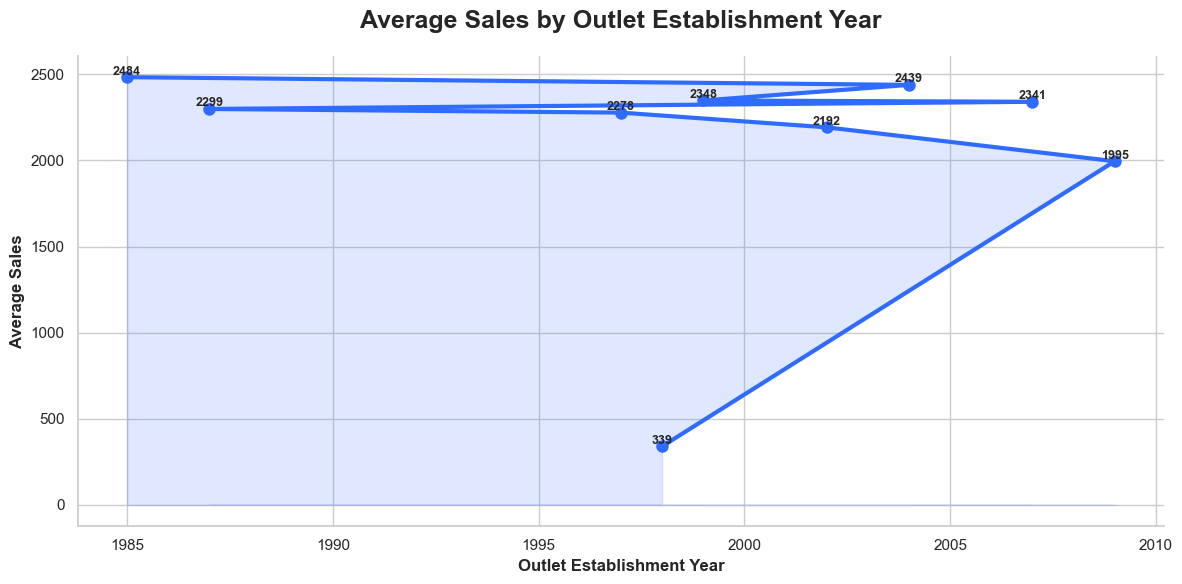

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Corporate theme
sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 6))

plt.plot(
    year_sales.index,
    year_sales.values,
    marker='o',
    linewidth=3,
    markersize=8,
    color='#2F6BFF'
)

# Fill area under line
plt.fill_between(
    year_sales.index,
    year_sales.values,
    alpha=0.15,
    color='#2F6BFF'
)

# Title
plt.title(
    "Average Sales by Outlet Establishment Year",
    fontsize=18,
    fontweight="bold",
    pad=20
)

# Axis labels
plt.xlabel(
    "Outlet Establishment Year",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Average Sales",
    fontsize=12,
    fontweight="bold"
)

# Data labels
for x, y in zip(year_sales.index, year_sales.values):
    plt.text(
        x,
        y + 15,
        f"{y:.0f}",
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

# Clean look
sns.despine()
plt.tight_layout()

plt.show()

In [30]:
#Sales Distribution (Basic Statistics)
sales_distribution = df["Item_Outlet_Sales"].describe()

print(sales_distribution)

count     8523.000000
mean      2181.288914
std       1706.499616
min         33.290000
25%        834.247400
50%       1794.331000
75%       3101.296400
max      13086.964800
Name: Item_Outlet_Sales, dtype: float64


In [31]:
#Skewness
print("Skewness:", df["Item_Outlet_Sales"].skew())

Skewness: 1.1775306028542798


In [32]:
#Kurtosis
print("Kurtosis:", df["Item_Outlet_Sales"].kurt())

Kurtosis: 1.615876681428729


In [33]:
#Sales Quartiles
Q1 = df["Item_Outlet_Sales"].quantile(0.25)
Q2 = df["Item_Outlet_Sales"].quantile(0.50)
Q3 = df["Item_Outlet_Sales"].quantile(0.75)

print("Q1:", Q1)
print("Median:", Q2)
print("Q3:", Q3)

Q1: 834.2474
Median: 1794.331
Q3: 3101.2964


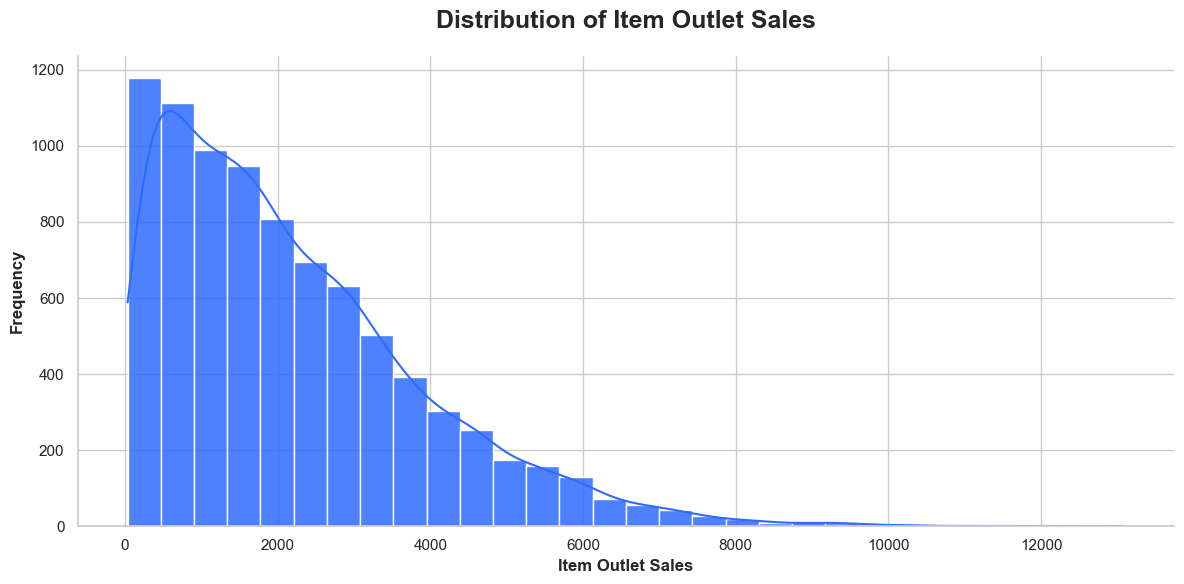

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Corporate theme
sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 6))

sns.histplot(
    data=df,
    x="Item_Outlet_Sales",
    bins=30,
    kde=True,
    color="#2F6BFF",
    edgecolor="white",
    alpha=0.85
)

plt.title(
    "Distribution of Item Outlet Sales",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.xlabel(
    "Item Outlet Sales",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Frequency",
    fontsize=12,
    fontweight="bold"
)

sns.despine()

plt.tight_layout()
plt.show()

In [36]:
#Product Category Distribution
product_distribution = (
    df["Item_Type"]
    .value_counts()
    .reset_index()
)

product_distribution.columns = ["Item_Type", "Count"]

print(product_distribution)

                Item_Type  Count
0   Fruits and Vegetables   1232
1             Snack Foods   1200
2               Household    910
3            Frozen Foods    856
4                   Dairy    682
5                  Canned    649
6            Baking Goods    648
7      Health and Hygiene    520
8             Soft Drinks    445
9                    Meat    425
10                 Breads    251
11            Hard Drinks    214
12                 Others    169
13          Starchy Foods    148
14              Breakfast    110
15                Seafood     64


C:\Users\zaim1\AppData\Local\Temp\ipykernel_5980\124175636.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


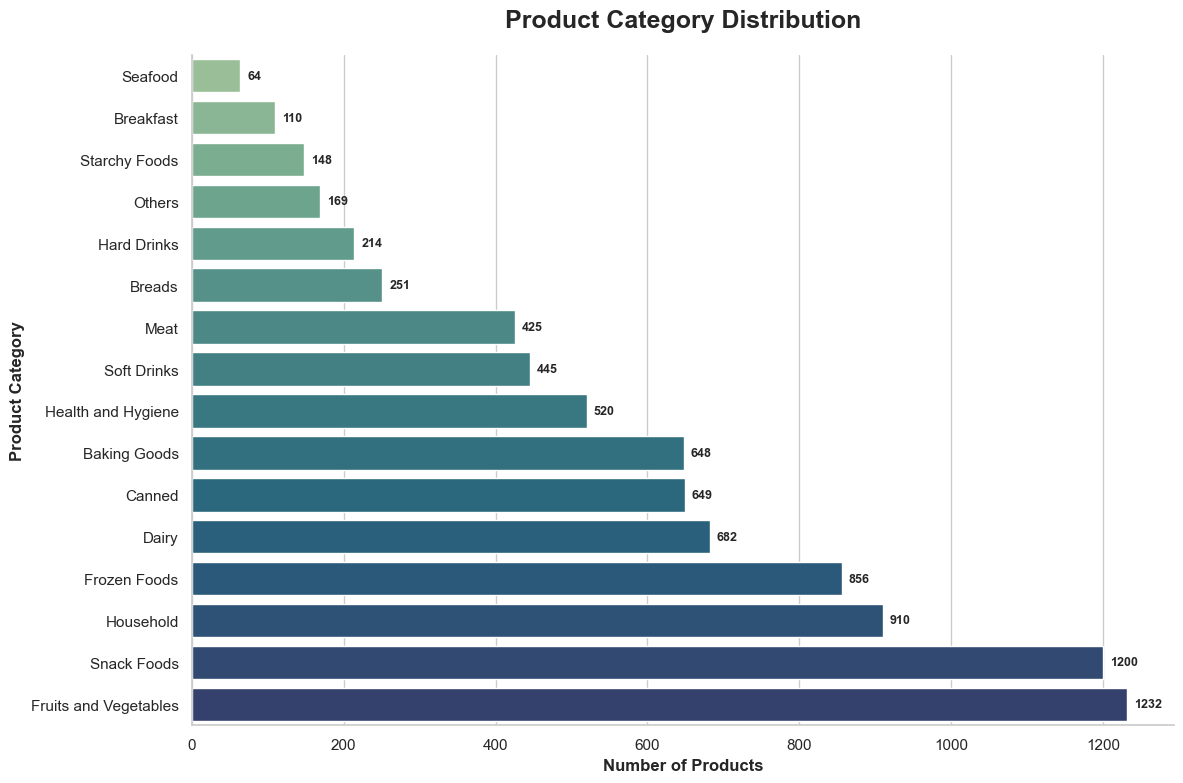

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort for better presentation
product_distribution = product_distribution.sort_values(
    by="Count",
    ascending=True
)

# Corporate theme
sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 8))

ax = sns.barplot(
    data=product_distribution,
    x="Count",
    y="Item_Type",
    palette="crest"
)

# Title
plt.title(
    "Product Category Distribution",
    fontsize=18,
    fontweight="bold",
    pad=20
)

# Axis labels
plt.xlabel(
    "Number of Products",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Product Category",
    fontsize=12,
    fontweight="bold"
)

# Value labels
for container in ax.containers:
    ax.bar_label(
        container,
        padding=5,
        fontsize=9,
        fontweight="bold"
    )

# Clean look
sns.despine()
plt.tight_layout()

plt.show()

<Axes: >

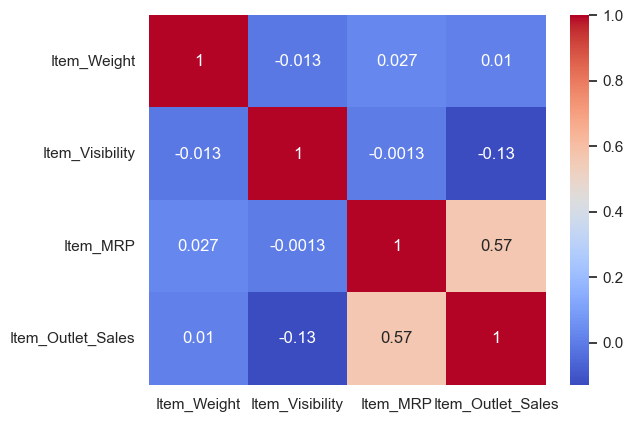

In [38]:
#correlation
num_cols = ["Item_Weight",
            "Item_Visibility",
            "Item_MRP",
            "Item_Outlet_Sales"]

sns.heatmap(df[num_cols].corr(),
            annot=True,
            cmap="coolwarm")

In [41]:
#For this project, I worked on the BigMart Retail Sales dataset to understand the factors that influence product sales across different outlets.
#The main objective of the project was to perform data cleaning, exploratory data analysis, and generate meaningful business insights from the available
#sales data. I used Python along with libraries such as Pandas, NumPy, Matplotlib, and Seaborn for the entire analysis process. I started by
#understanding the structure of the dataset and checking for missing values, duplicates, data types, and basic statistics. During the data cleaning 
#stage, I found missing values in the Item Weight and Outlet Size columns. Instead of removing the rows and losing valuable information, I handled 
#the missing values using appropriate imputation techniques. For Item Weight, I filled the missing values using the median weight within each Item 
#Type category, which helped preserve the characteristics of similar products. For Outlet Size, I used the mode value because it is a categorical 
#feature. I also standardized the Item Fat Content column because it contained inconsistent values such as "LF", "low fat", and "reg", which were 
#converted into their respective standard categories. After cleaning the dataset, I performed exploratory data analysis to understand sales patterns
#and customer behavior. I first analyzed Item Type versus Total Sales to identify which product categories contributed the highest revenue.
#    The analysis showed that categories such as Fruits and Vegetables, Snack Foods, and Household products generated significant sales, indicating
#their importance in the overall business. Next, I compared Outlet Type with Average Sales and found that supermarket formats generally performed
#better than grocery stores, suggesting that larger retail formats attract more customers and generate higher revenue. I also examined the 
#relationship between Outlet Size and Sales and observed that medium and large outlets tended to achieve better sales performance compared to 
#smaller outlets. To understand customer preferences, I analyzed Fat Content versus Sales and found that regular products contributed a larger 
#share of revenue than low-fat products. This indicates that customers still purchase a significant number of traditional products despite increasing
#health awareness. I then investigated the relationship between Item Visibility and Sales using correlation analysis and scatter plots. 
#    The correlation value was weak and slightly negative, suggesting that higher visibility alone does not guarantee increased sales. 
#    This was an interesting finding because it showed that other factors such as pricing, product category, and store characteristics may
#play a more important role in driving sales. Another important analysis was Item MRP versus Sales. The results indicated a positive relationship 
#between product price and sales revenue, suggesting that higher-priced products often contribute more revenue to the business. I also analyzed
#Outlet Location Type versus Sales to compare performance across different city tiers. The findings showed that Tier 3 locations performed strongly,
#highlighting the importance of non-metro markets in retail growth. To understand whether store age impacts performance, I analyzed Outlet
#Establishment Year versus Sales and found variations across years, suggesting that factors such as market conditions, location, and customer 
#loyalty can influence long-term sales performance. I further studied the distribution of sales using histograms and density plots.
#    The sales data showed a positively skewed distribution, meaning that most products generated moderate sales while a smaller number
#of products achieved very high sales. This pattern is common in retail businesses where a few products contribute a significant portion
#of total revenue. I also analyzed the distribution of products across different categories and found that categories such as Fruits and 
#Vegetables, Snack Foods, and Household products had the highest representation in the inventory. In addition to individual analyses,
#I created a correlation heatmap to examine relationships among numerical variables including Item Weight, Item Visibility, Item MRP,
#and Item Outlet Sales. The heatmap confirmed that pricing had a stronger relationship with sales compared to visibility and product weight.
#    Throughout the project, I created more than ten visualizations including bar charts, scatter plots, line charts, histograms, donut charts,
#boxplots, and a correlation heatmap. These visualizations helped transform raw data into understandable insights and supported business
#decision-making. Based on the findings, I concluded that product category, outlet type, pricing, outlet size, and location are important 
#factors affecting sales performance. The project strengthened my understanding of data cleaning, missing value treatment, exploratory data 
#analysis, visualization techniques, correlation analysis, and business insight generation. It also helped me gain practical experience in
#using Python for real-world retail analytics and demonstrated how data can be used to support strategic business decisions.
#    This project reflects my ability to work with structured datasets, identify meaningful patterns, and communicate analytical findings
#    effectively through visualizations and data-driven recommendations.